c:\Users\Vaishnavi\OneDrive\Desktop\Customer_Churn\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Model loaded successfully!
Accuracy: 0.8587650816181689

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.71      0.73       374
           1       0.74      0.64      0.69        91
           2       0.91      0.94      0.92       944

    accuracy                           0.86      1409
   macro avg       0.80      0.76      0.78      1409
weighted avg       0.86      0.86      0.86      1409



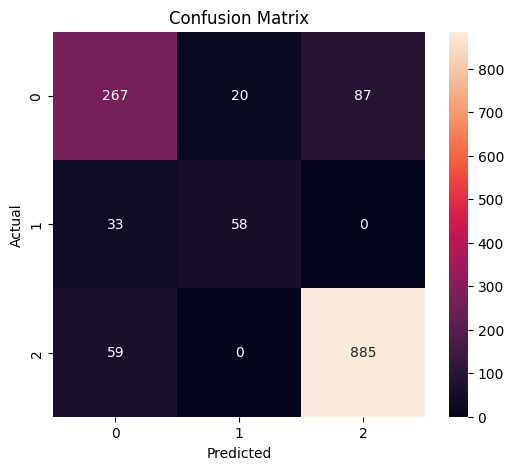

✅ SHAP values calculated!


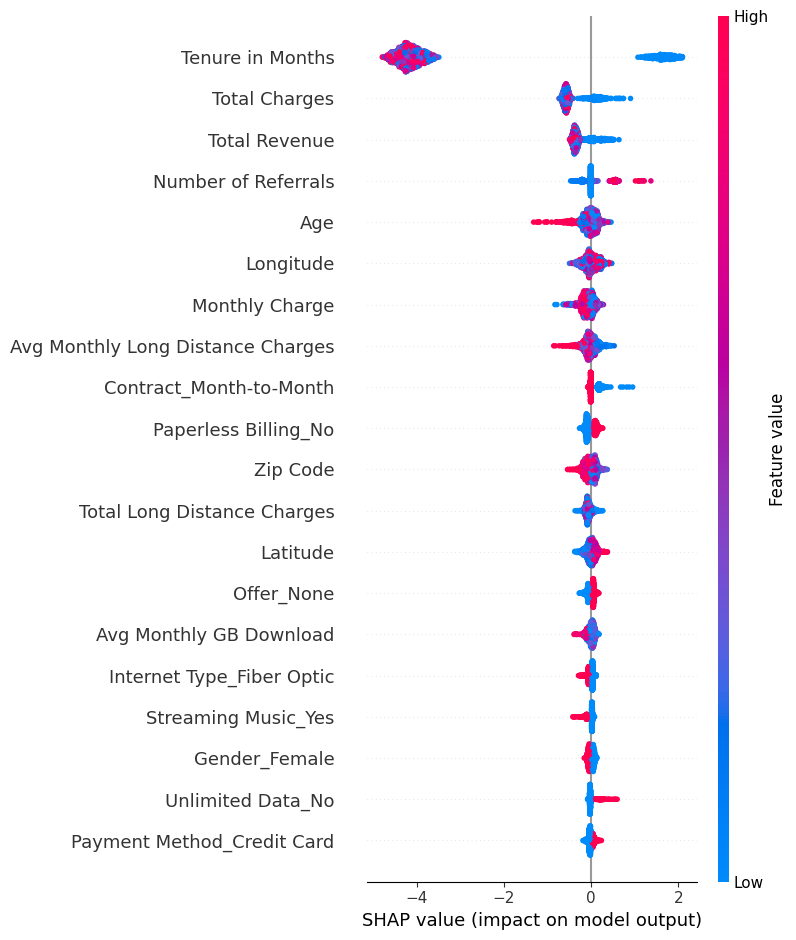

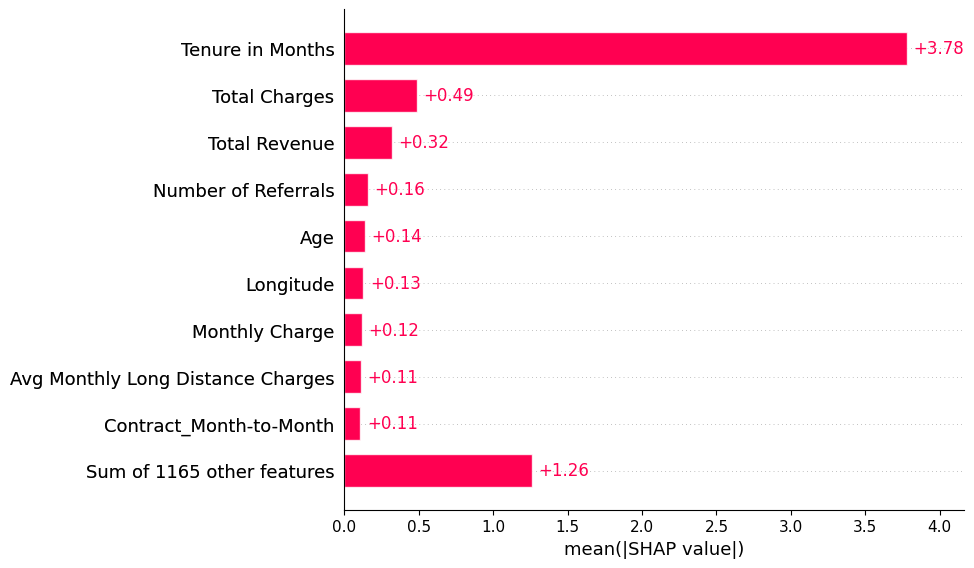

In [1]:
# =====================================================
# 1️⃣ Import Libraries
# =====================================================
import pandas as pd
import pickle
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


# =====================================================
# 2️⃣ Load Model
# =====================================================
with open("artifacts/xgb_churn_model.pkl", "rb") as f:
    model = pickle.load(f)

print("✅ Model loaded successfully!")


# =====================================================
# 3️⃣ Load Data
# =====================================================
test_df = pd.read_csv("datasets/test_data.csv")

X_test = test_df.drop("Customer Status", axis=1)
y_test = test_df["Customer Status"]


# =====================================================
# 4️⃣ Ensure Columns Match Training (CRITICAL)
# =====================================================
model_columns = pickle.load(open("artifacts/model_columns.pkl", "rb"))

# Align columns
X_test = pd.get_dummies(X_test)

for col in model_columns:
    if col not in X_test:
        X_test[col] = 0

X_test = X_test[model_columns]


# =====================================================
# 5️⃣ Predictions
# =====================================================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# =====================================================
# 6️⃣ Confusion Matrix
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# =====================================================
# 7️⃣ SHAP Explainer (CORRECT WAY)
# =====================================================
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

print("✅ SHAP values calculated!")


# =====================================================
# 8️⃣ Global Feature Importance
# =====================================================
# For multiclass → pick one class (churn = 1)
class_index = 1

shap.summary_plot(
    shap_values[:, :, class_index],
    X_test
)


# =====================================================
# 9️⃣ Bar Plot (Clean Importance)
# =====================================================
shap.plots.bar(
    shap_values[:, :, class_index]
)


# =====================================================
# 🔟 Explain Single Customer
# =====================================================
shap.initjs()

# Pick first sample
i = 0

shap.plots.force(
    shap_values[i, :, class_index]
)

In [2]:
import pickle

with open("shap_values.pkl", "wb") as f:
    pickle.dump(shap_values, f)

print("SHAP values saved successfully!")

SHAP values saved successfully!


In [3]:
with open("shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)